In [6]:
from mydataset.e3sm_seq_overlap import Climate240
from models.CDC import keyframe_compressor as compress_modules
import torch
import torch.nn as nn
import importlib
import models
from torch.utils.data import DataLoader, ConcatDataset


importlib.reload(compress_modules)
from models.CDC import keyframe_compressor as compress_modules

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [7]:
from collections import OrderedDict


def remove_module_prefix(state_dict):
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        new_key = k.replace("module.", "")  # remove 'module.' prefix
        new_state_dict[new_key] = v
    return new_state_dict


def load_model(pretrain_vae):
    keyframe_model = compress_modules.ResnetCompressor()
    keyframe_model.load_pretrain(pretrain_vae)
    keyframe_model = keyframe_model.to(device).eval()
    return keyframe_model

In [8]:
def domain_arg(test_set = "S3D"):
    
    if test_set == "E3SM":
        data_arg = {"data_path":"/blue/ranka/shared-xiaoli/ScientificDataset/E3SM/e3sm_1.npz",
                    "variable_idx": [0],
                    "section_range": [0,6],
                    "frame_range": [0,721],
                    "n_frame":1,
                    "n_overlap":0,
                    "train": False,
                    "train_size":256,
                    "test_size":(256,256),
                    "inst_norm": True, "norm_type":'mean_range'}

        valid_length = 720

    elif  test_set == "S3D":

        data_arg = {"data_path":"/blue/ranka/shared-xiaoli/ScientificDataset/S3D/s3d.npz",
                    "name":"S3D",
                    "variable_idx": [8],
                    "section_range": [0,1],
                    "frame_range": [0,46],
                    "n_frame":1,
                    "n_overlap":0,
                    "train": False,
                    "train_size":256,
                    "test_size":(256,256),
                    "resolution":(512,512),
                    "inst_norm": True, "norm_type":'mean_range'}

        valid_length = 46


    elif test_set == "JHTDB":

        data_arg = {"data_path":"/blue/ranka/shared-xiaoli/ScientificDataset/JHTDB/JHTDB.npz",
                    "name":"JHTDB",
                    "variable_idx": [0],
                    "section_range": [48, 56],
                    "frame_range": [0,121],
                    "n_frame":1,
                    "n_overlap":0,
                    "train": False,
                    "train_size":256,
                    "test_size":(256,256),
                    "inst_norm": True, "norm_type":'mean_range'}

        valid_length = 120
        
    return data_arg, valid_length

In [1]:
24*256*256*256*4/1024**3

1.5

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


In [9]:
from torch.utils.data import DataLoader
from time import time
import numpy as np
from tools_online.io.json_io import save_json
import torch.nn.functional as F



def evaluate_model(model,dataset_org):
    dataloader =  DataLoader(dataset_org, batch_size=64, shuffle=False, num_workers=2)
    
    temp_recons_data = torch.zeros_like(dataset_org.data_input)
    # diffusion.num_timesteps = 1000
    total_bits = 0
    
    with torch.no_grad():
        for data in dataloader:
            input_data = data["input"]
            pixel_shape = input_data.shape
            batch_size = pixel_shape[0]


            keyframe = input_data.cuda()
            compressed_data, nbits_each_frame = model.compress(keyframe)
            total_bits += torch.sum(nbits_each_frame)

            latent_data = model.decompress(*compressed_data, device = device)
            B,C,KT,H,W = latent_data.shape

            input_latent = latent_data.permute(0,2,1,3,4).reshape(-1,64,16,16)

            rct_data = model.decode(input_latent).detach().reshape(pixel_shape)*data["scale"].cuda() + data["offset"].cuda()
            rct_data = rct_data.cpu()

            for i in range(batch_size):
                idx0, idx1, start_t, end_t = data["index"]
                temp_recons_data[idx0[i], idx1[i], start_t[i]:end_t[i]] = rct_data[i]
                
    return temp_recons_data, total_bits.cpu()

In [10]:
from mydataset.dataset import ScientificDataset


pretrain_vae = "./snapshots/vae/S3D_ds/pretrain_on_5Sets_pipeline/model_bs32_ep300k.pt"
domains = ["S3D", "E3SM", "JHTDB"]


model = load_model(pretrain_vae)

for i in [0]: 
    
    data_arg, valid_length = domain_arg(domains[i])
    dataset_org = ScientificDataset(data_arg)
    temp_recons_data, total_bits = evaluate_model(model, dataset_org)


    original_data = dataset_org.original_data()
    recons_data   = dataset_org.deblocking_hw(temp_recons_data)

    valid_orgdata = original_data[:,:,:valid_length]
    valid_rctdata = recons_data[:,:,:valid_length]
    
    axis = (0, 1, 2, 3, 4)
    
    nrmse = torch.sqrt(torch.mean((valid_orgdata - valid_rctdata) ** 2, dim=axis)) / (torch.max(valid_orgdata) - torch.min(valid_orgdata))
    cr = np.prod(original_data.shape)*32/total_bits
    
    print(domains[i], nrmse.item(), "CR:", cr.item())

Loaded pretrained weights from ./snapshots/vae/S3D_ds/pretrain_on_5Sets_pipeline/model_bs32_ep300k.pt
*************** Loading S3D ***************
Original Data Shape (1, 1, 46, 512, 512)
Testing Data Shape torch.Size([1, 4, 46, 256, 256])
torch.Size([64, 64, 16, 16]) torch.Size([64, 64, 4, 4])
nbits_theory tensor([13127.9775, 13009.0039, 12931.4561, 12773.1826, 12731.6494, 12638.4746,
        12546.3574, 12478.4707, 12440.4717, 12215.9932, 12349.2900, 12150.5449,
        12158.1016, 12123.6133, 12033.2578, 12081.0508, 11965.9209, 11926.3438,
        11923.4229, 11842.0830, 11720.1777, 11705.7734, 11680.8203, 11618.9805,
        11491.6348, 11370.7314, 11344.6709, 11320.4102, 11363.5254, 11212.6982,
        11202.2314, 11075.1631, 10919.4512, 10839.4160, 10830.7676, 10686.1182,
        10687.1670, 10657.4102, 10611.4727, 10510.1338, 10539.9062, 10456.5391,
        10571.9785, 10342.6904, 10319.5254, 10217.9551, 12454.7480, 12129.7852,
        12010.7012, 11984.3018, 11990.0957, 11738.09

In [1]:
# Loaded pretrained weights from ./snapshots/vae/e3sm/train_on_SHPJ/model_bs32_ep400k_final.pt
# *************** Loading S3D ***************
# Original Data Shape (1, 1, 46, 512, 512)
# Testing Data Shape torch.Size([1, 4, 46, 256, 256])
# S3D 0.0008983130101114511 CR: tensor(174.4848)
# *************** Loading E3SM ***************
# Original Data Shape (1, 6, 721, 240, 240)
# Testing Data Shape torch.Size([1, 6, 721, 256, 256])
# E3SM 0.0011842247331514955 CR: tensor(80.4529)
# *************** Loading JHTDB ***************
# Original Data Shape (1, 8, 121, 512, 512)
# Testing Data Shape torch.Size([1, 32, 121, 256, 256])
# JHTDB 0.002205737866461277 CR: tensor(54.4036)

In [38]:
np.savez("../LatentDiffusion/data/E3SM/train_on_SHPJ.npz", original_data = x, recons_data = y, 
         latent_bit = total_bits,
         vae_path = pretrain,
         diffusion_path = diffusion_path)

In [36]:
depad = 8
recons_data2  = recons_data[...,depad:-depad,depad:-depad].reshape([-1, 30, 8, 30, 8]).transpose([0,1,3,2,4]).reshape([-1, 64]).astype(np.float32)
original_data2  = original_data[...,depad:-depad,depad:-depad].reshape([-1, 30, 8, 30, 8]).transpose([0,1,3,2,4]).reshape([-1, 64]).astype(np.float32)
original_data2.dtype, recons_data2.shape, original_data2.shape

save_data = True

if save_data:
    np.savez("../LatentDiffusion/data/FMCLD/firstNoInstNorm.npz", 
             original_data = original_data2,  recons_data = recons_data2, latent_bit = int(bit_count), 
             path = pretrain,
             path_diffusion = diffusion_path)

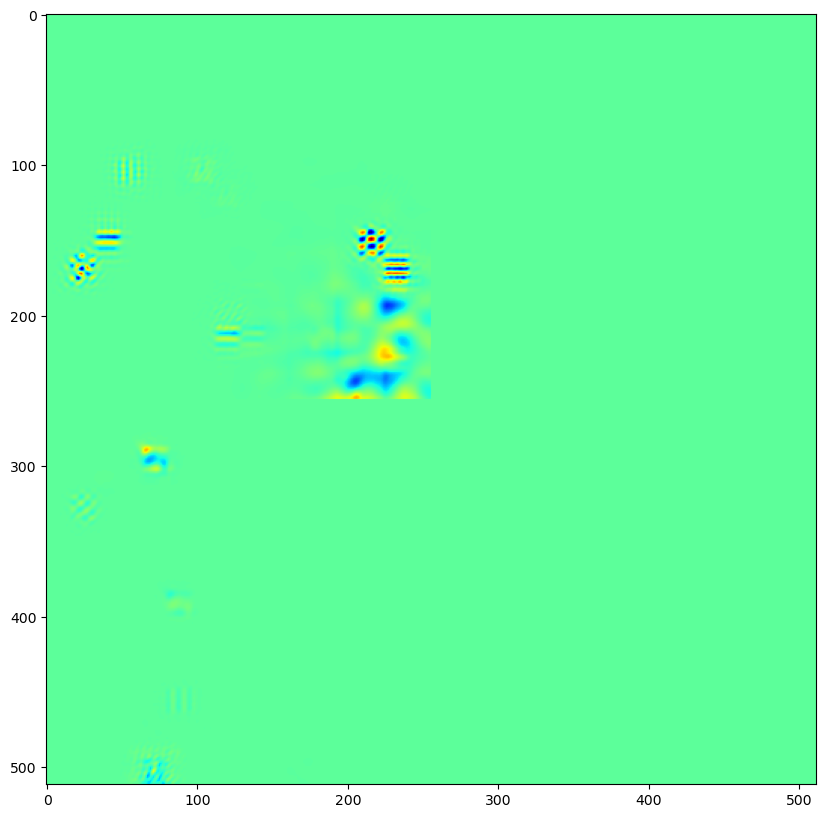

In [41]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import imageio
import numpy as np
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(16,10))

video = valid_rctdata[0,0]
# video = recons_data[:,0]

im = ax.imshow(video[0], cmap="jet")

def update(frame):
    im.set_array(video[frame])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(video), interval=1)

# Save as a GIF
ani.save("animation.gif", writer=animation.PillowWriter(fps=5))

# Display in Jupyter Notebook
HTML(ani.to_jshtml())